In [1]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
import networkx as nx
from difflib import get_close_matches
from scipy.stats import chi2_contingency
import numpy as np
import seaborn as sns
import unicodedata
import re
from collections import Counter, defaultdict
from matplotlib.patches import Patch

c:\Users\dav-9\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Actor

In [2]:
# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

#print("Path to dataset files:", path)
#print("Fichiers dans le dossier :")
#print(os.listdir(path))

file_path_movie = os.path.join(path, "tmdb_5000_movies.csv")
file_path_credits = os.path.join(path, "tmdb_5000_credits.csv")

movies   = pd.read_csv(file_path_movie)
credits  = pd.read_csv(file_path_credits)

# Vérifier les colonnes
#print(credits.columns)
#print(movies.columns)

# Faire la jointure sur movie_id (credits) et id (movies)
data = movies.merge(credits, left_on='id', right_on='movie_id', how='inner')

"""print(data.shape)
col = data.columns.tolist()
for i in range(0, len(col), 5) :
    if (i + 5 <= len(col)) :
        print(col[i : i + 5])
    else :
        print(col[i:])
print(data.head())"""

'print(data.shape)\ncol = data.columns.tolist()\nfor i in range(0, len(col), 5) :\n    if (i + 5 <= len(col)) :\n        print(col[i : i + 5])\n    else :\n        print(col[i:])\nprint(data.head())'

In [3]:
def get_top_actors(cast_json, nbr) :
    try :
        cast_list = json.loads(cast_json)
        top = [actor['name'] for actor in cast_list]
        while len(top) < nbr :
            top.append(None)
        return top[:nbr]
    except :
        return [None] * nbr

def get_imdb_graph(data, nbr_actors=3, firstyear=1, lastyear=3000, genre=None, minscore=0, maxscore=10) :

    df = data.copy()

    # Filtre par genre
    if genre is not None:
        df = df[df['genres'].str.contains(genre, na=False)]

    # S'assurer que release_date est bien en datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    # Extraire l'année
    df['release_year'] = df['release_date'].dt.year
    # Filtre par année et score
    df = df[(df['release_year'] >= firstyear) &
            (df['release_year'] <= lastyear) &
            (df['vote_average'] >= minscore) &
            (df['vote_average'] <= maxscore)]

    # Sélection des colonnes utiles
    df = df[['original_title', 'cast', 'release_year']]

    # Garder seulement les lignes où 'cast' contient au moins nbr_actors acteurs
    #df = df[df['cast'].apply(lambda x: len(json.loads(x)) >= nbr_actors)]

    # Une seule colonne 'actors' contenant une liste
    df['actors'] = df['cast'].apply(lambda x: get_top_actors(x, nbr_actors))

    # Création du graphe
    G = nx.Graph()

    for _, row in df.iterrows() :
        # Retirer les valeurs None de la liste
        actors = [a for a in row['actors'] if pd.notna(a)]

        # Ajouter toutes les combinaisons d'acteurs
        if len(actors) >= 2 :
            for i in range(len(actors)) :
                for j in range(i + 1, len(actors)) :
                    G.add_edge(actors[i], actors[j])

    return G

In [4]:
G = get_imdb_graph(data, nbr_actors=10, firstyear=1990, lastyear=2009)

print("\tNombre d'acteurs :", G.number_of_nodes())
print("\tNombre de collaborations :", G.number_of_edges())

	Nombre d'acteurs : 11637
	Nombre de collaborations : 111299


# MBTI

In [5]:
path_mbti = kagglehub.dataset_download("yuraslastya/celeb-mbti")

file_path_mbti = os.path.join(path_mbti, "mbti_celebrities.csv")

mbti = pd.read_csv(file_path_mbti)

cols = ['name', 'category', 'subcategory', 'four_letter', 'letter_1', 'letter_1_percentage',
    'letter_2', 'letter_2_percentage', 'letter_3', 'letter_3_percentage', 'letter_4', 'letter_4_percentage']

mbti = mbti[cols]

print(f"Nombre de lignes avant nettoyage : {len(mbti)}")

mbti = mbti.drop_duplicates()

print(f"Nombre de lignes après nettoyage : {len(mbti)}")


Nombre de lignes avant nettoyage : 50878
Nombre de lignes après nettoyage : 50791


In [6]:
# Récupérer les acteurs du graphe
actors_in_graph = set(G.nodes())
# Récupérer les acteurs dans la db MBTI
actors_in_mbti = set(mbti['name'].tolist())
# Intersection : acteurs présents dans les deux
common_actors = actors_in_graph & actors_in_mbti

# Pour chaque acteur du graphe, chercher le nom le plus proche dans MBTI
mbti_names = set(mbti['name'].tolist())
mbti_names = list(mbti_names - common_actors) # on enleve les perfect match
actors_in_graph = actors_in_graph - common_actors # on enleve les perfect match
matched = {}

for actor in actors_in_graph :
    matches = get_close_matches(actor, mbti_names, n=1, cutoff=0.9)
    if matches :
        matched[actor] = matches[0]

print(f"Acteurs matchés (approx)  : {len(matched):,}")
"""print("\nNoms match :")
for original, match in list(matched.items()) :
    if original != match :
        print(f"  {original:<30} match '{match}'")"""

Acteurs matchés (approx)  : 223


'print("\nNoms match :")\nfor original, match in list(matched.items()) :\n    if original != match :\n        print(f"  {original:<30} match \'{match}\'")'

In [7]:
def same_person(name1, name2) :
    def normalize(name) :
        # remplacer ., ', ’ et , par des espaces
        name = name.replace('.', ' ').replace(',', ' ').replace('’', ' ').replace("'", ' ')
        
        # enlever les accents
        name = unicodedata.normalize('NFKD', name)
        name = name.encode('ascii', 'ignore').decode('utf-8')
        
        # mettre en minuscule
        name = name.lower()
        
        # enlever les espaces multiples
        name = re.sub(r'\s+', ' ', name)
        
        # trim (espaces début/fin)
        name = name.strip()
        
        return name
    
    return normalize(name1) == normalize(name2)

valid_match = {}
invalid_match = {}
for original, match in list(matched.items()) :
    if same_person(original, match) :
        valid_match[original] = match
    else :
        invalid_match[original] = match

In [8]:
# Récupérer les acteurs du graphe
actors_in_graph = set(G.nodes())

# convertir en dict inverse
valid_inverse = {v: k for k, v in valid_match.items()}
# Récupérer les acteurs dans la db MBTI
mbti['name_cleaned'] = mbti['name'].replace(valid_inverse)
actors_in_mbti = set(mbti['name_cleaned'].tolist())

# Intersection : acteurs présents dans les deux
common_actors = actors_in_graph & actors_in_mbti

print(f"Acteurs dans le graphe         : {len(actors_in_graph):,}")
print(f"Célébrités dans MBTI           : {len(actors_in_mbti):,}")
print(f"Acteurs en commun              : {len(common_actors):,}")

Acteurs dans le graphe         : 11,637
Célébrités dans MBTI           : 50,640
Acteurs en commun              : 2,446


# Graph

In [9]:
# On garde les colonnes voulues + l'index
cols_to_keep = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

# 'index' crée un dictionnaire de type {nom: {col1: val1, col2: val2...}}
mbti_unique = mbti.drop_duplicates(subset=['name_cleaned'], keep='first')

# 2. Maintenant on peut créer le dictionnaire sans erreur
mbti_dict = mbti_unique.set_index('name_cleaned')[cols_to_keep].to_dict(orient='index')

for actor in G.nodes() :
    # mbti_data sera soit le dict des 4 lettres, soit None
    mbti_data = mbti_dict.get(actor) 
    
    if mbti_data :
        # On injecte directement les 4 clés/valeurs dans le noeud
        G.nodes[actor].update(mbti_data)
        
        #full_type = "".join([mbti_data[f'letter_{i}'] for i in range(1, 5)])
        #G.nodes[actor]['mbti_full'] = full_type
    else :
        # Ajouter "Unknown" pour chaque lettre
        for col in cols_to_keep:
            G.nodes[actor][col] = "Unknown"

# Vérifier
actors_with_mbti = [(n, d['letter_1']) for n, d in G.nodes(data=True) if 'letter_1' in d]
print(f"\nActeurs du graphe avec MBTI : {len(actors_with_mbti)}")
print("\nExemples :")
for name, mbti_type in actors_with_mbti[:10] :
    print(f"  {name:<30} : {mbti_type}")


Acteurs du graphe avec MBTI : 11637

Exemples :
  Sam Worthington                : I
  Zoe Saldana                    : I
  Sigourney Weaver               : I
  Stephen Lang                   : I
  Michelle Rodriguez             : E
  Giovanni Ribisi                : I
  Joel David Moore               : Unknown
  CCH Pounder                    : Unknown
  Wes Studi                      : Unknown
  Laz Alonso                     : E


In [10]:
print("\tNombre d'acteurs :", G.number_of_nodes())
print("\tNombre de collaborations :", G.number_of_edges())
print(G.nodes)

	Nombre d'acteurs : 11637
	Nombre de collaborations : 111299
['Sam Worthington', 'Zoe Saldana', 'Sigourney Weaver', 'Stephen Lang', 'Michelle Rodriguez', 'Giovanni Ribisi', 'Joel David Moore', 'CCH Pounder', 'Wes Studi', 'Laz Alonso', 'Johnny Depp', 'Orlando Bloom', 'Keira Knightley', 'Stellan Skarsgård', 'Chow Yun-fat', 'Bill Nighy', 'Geoffrey Rush', 'Jack Davenport', 'Kevin McNally', 'Tom Hollander', 'Tobey Maguire', 'Kirsten Dunst', 'James Franco', 'Thomas Haden Church', 'Topher Grace', 'Bryce Dallas Howard', 'Rosemary Harris', 'James Cromwell', 'J.K. Simmons', 'Theresa Russell', 'Daniel Radcliffe', 'Rupert Grint', 'Emma Watson', 'Tom Felton', 'Michael Gambon', 'Jim Broadbent', 'Helena Bonham Carter', 'Robbie Coltrane', 'Maggie Smith', 'Alan Rickman', 'Brandon Routh', 'Kevin Spacey', 'Kate Bosworth', 'James Marsden', 'Parker Posey', 'Frank Langella', 'Sam Huntington', 'Eva Marie Saint', 'Marlon Brando', 'Kal Penn', 'Daniel Craig', 'Olga Kurylenko', 'Mathieu Amalric', 'Judi Dench', '

Homophilie :

> Le lift indique la tendance selon laquel les individus tendent à nouer des liens avec des personnes similaires à eux-mêmes (1.0 = pur hasard).

Noeuds total   : 11,637
Noeuds connus  : 2,446  (21.0%)
Noeuds Unknown : 9,191

══════ Homophilie par dimension MBTI ══════
  letter_1  | Observé=0.531  Attendu=0.510  Lift=1.04x  (sur 26,128 arêtes)
  letter_2  | Observé=0.527  Attendu=0.513  Lift=1.03x  (sur 26,128 arêtes)
  letter_3  | Observé=0.517  Attendu=0.521  Lift=0.99x  (sur 26,128 arêtes)
  letter_4  | Observé=0.526  Attendu=0.514  Lift=1.02x  (sur 26,128 arêtes)


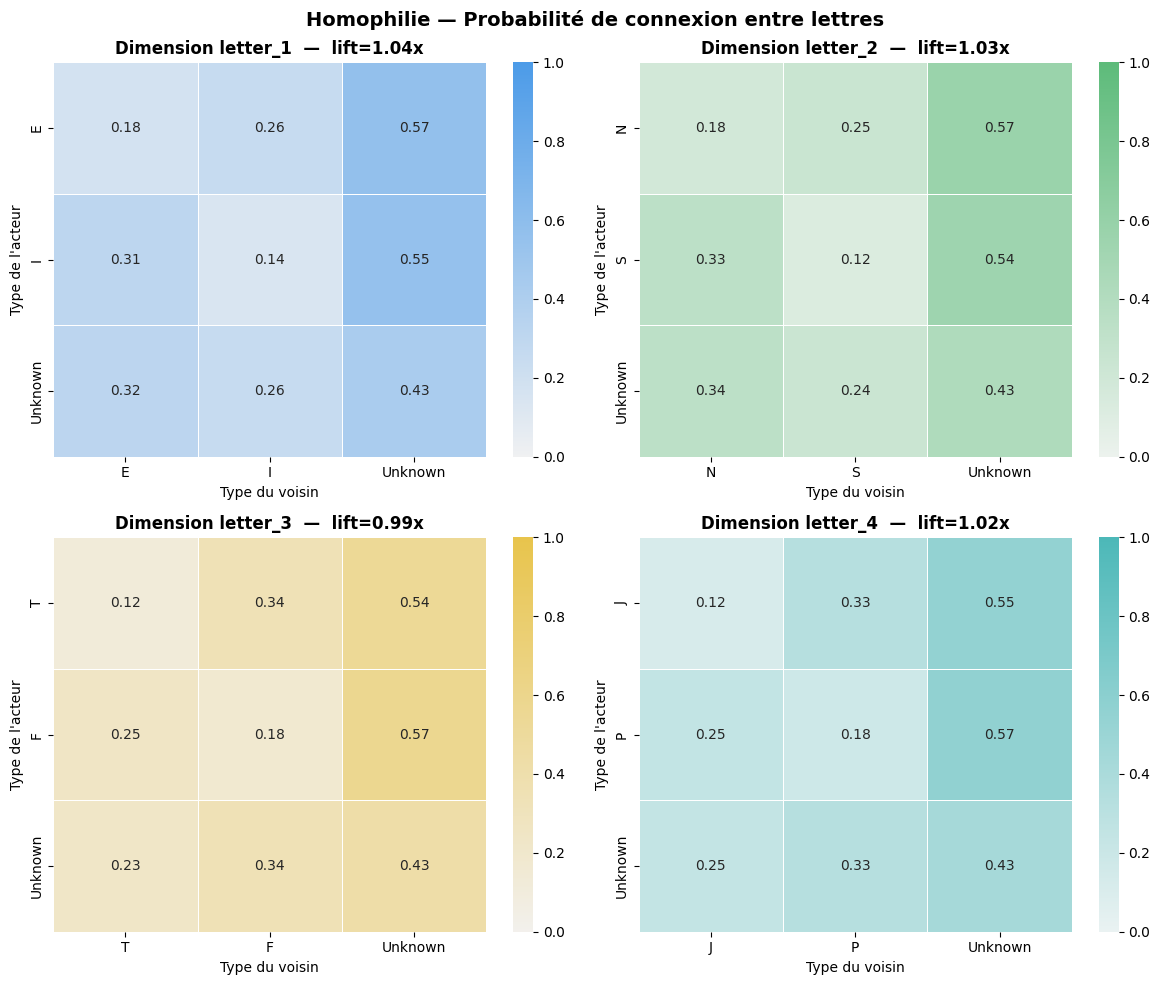

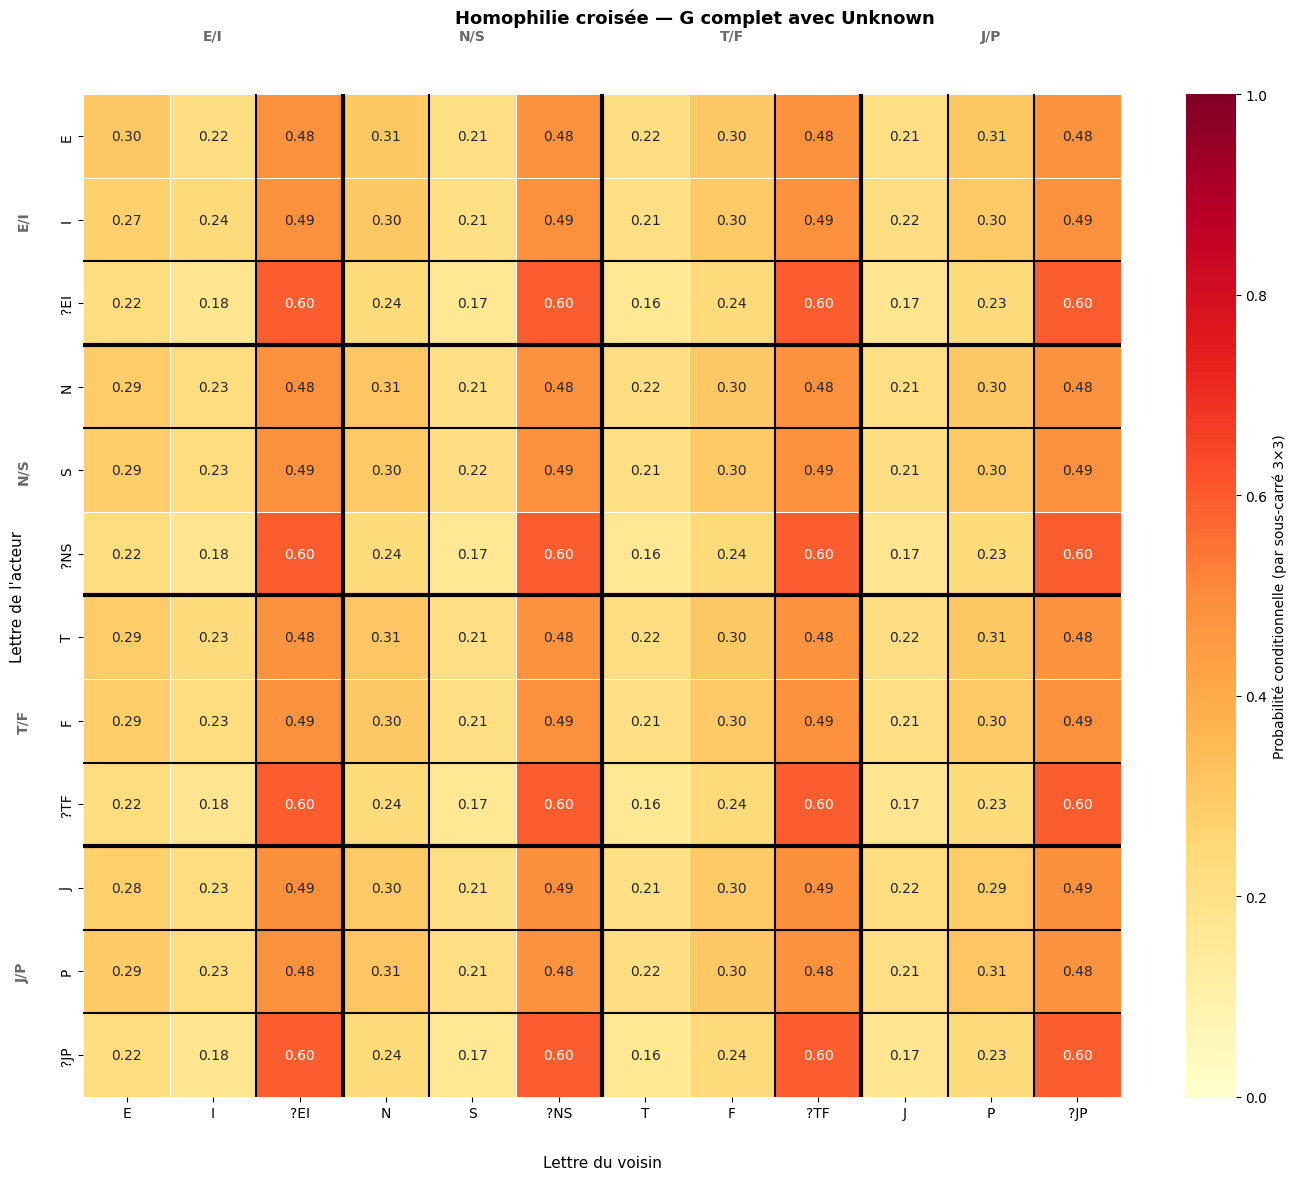

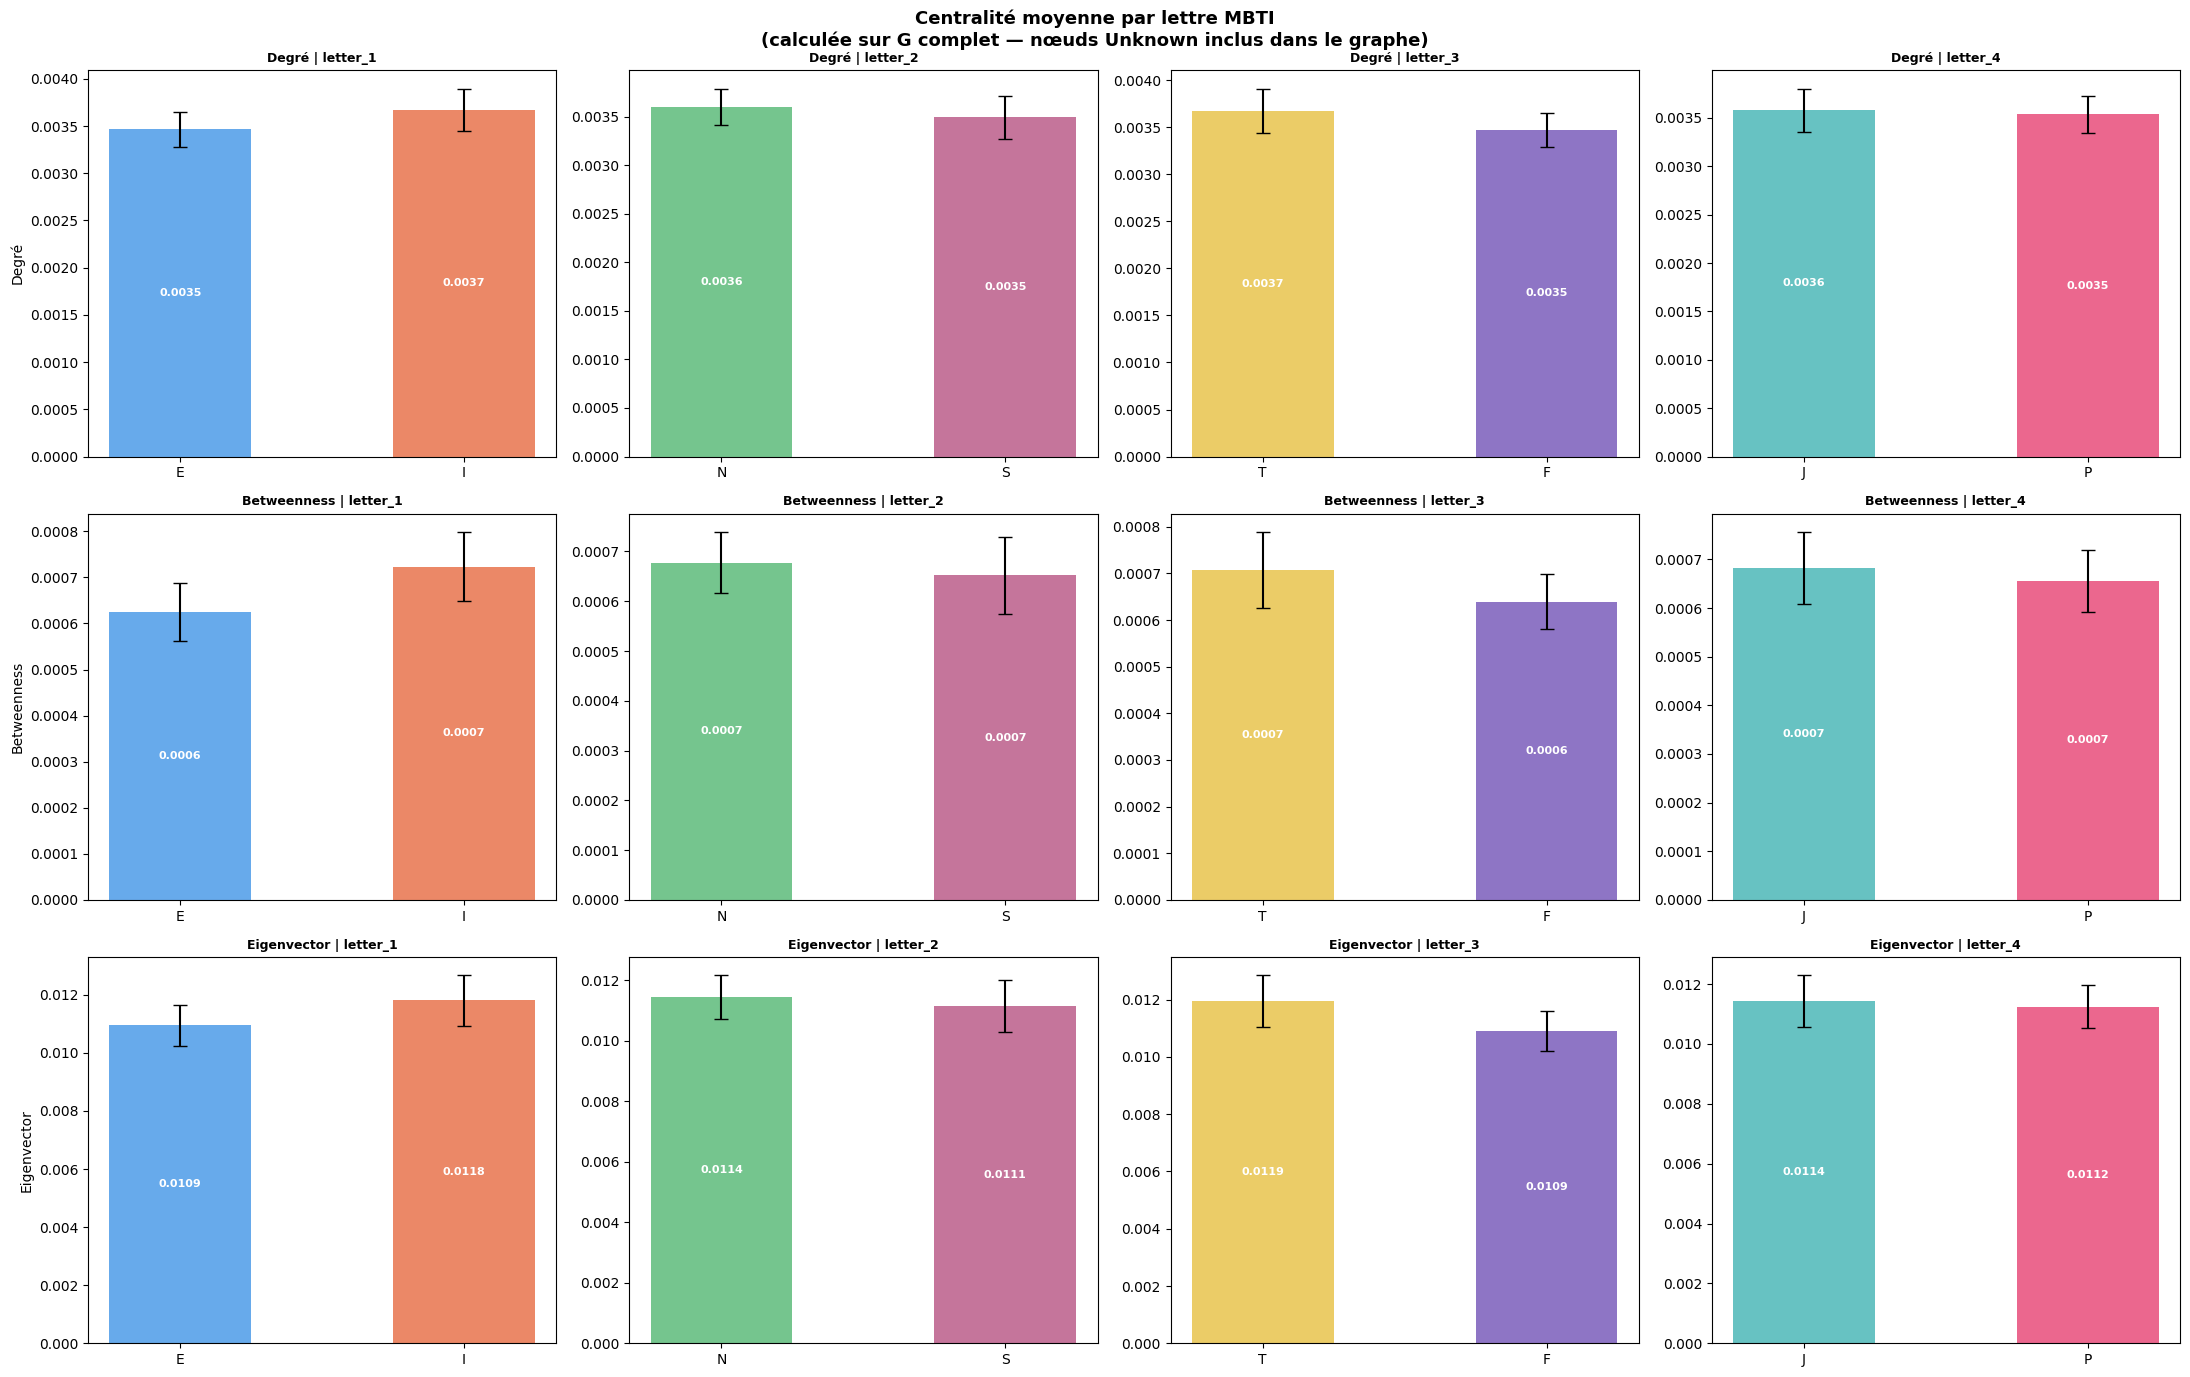


══════ Top 10 acteurs par betweenness — G complet ══════
                  letter_1 letter_2 letter_3 letter_4  betweenness_c_full
actor                                                                    
Samuel L. Jackson        E        S        T        P            0.016478
Morgan Freeman           I        S        T        J            0.008783
Bruce Willis             I        S        F        J            0.008674
Brad Pitt                I        S        F        P            0.008480
Robin Williams           E        N        F        P            0.008139
Nicolas Cage             I        N        F        P            0.007933
Jackie Chan              E        N        F        P            0.007557
Robert De Niro           I        S        T        J            0.007432
Willem Dafoe             E        N        F        J            0.007103
Brian Cox                E        N        T        P            0.007097


In [20]:
DIMENSIONS = {
    "letter_1": ("E", "I"),
    "letter_2": ("N", "S"),
    "letter_3": ("T", "F"),
    "letter_4": ("J", "P"),
}

DIM_COLORS = {
    "letter_1": ("#4C9BE8", "#E8734C"),
    "letter_2": ("#5DBB7A", "#BB5D8A"),
    "letter_3": ("#E8C44C", "#7A5DBB"),
    "letter_4": ("#4CB8B8", "#E84C7A"),
}

nodes_df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
nodes_df.index.name = "actor"

known_df = nodes_df[nodes_df[['letter_1', 'letter_2', 'letter_3', 'letter_4']].ne("Unknown").all(axis=1)].copy()
print(f"Noeuds total   : {len(nodes_df):,}")
print(f"Noeuds connus  : {len(known_df):,}  ({100*len(known_df)/len(nodes_df):.1f}%)")
print(f"Noeuds Unknown : {len(nodes_df)-len(known_df):,}")

# HOMOPHILIE

def homophily_score(G, attribute):
    same = total = 0
    for u, v in G.edges():
        a1 = G.nodes[u].get(attribute, "Unknown")
        a2 = G.nodes[v].get(attribute, "Unknown")
        if a1 == "Unknown" or a2 == "Unknown":
            continue
        total += 1
        if a1 == a2:
            same += 1
    observed = same / total if total > 0 else 0
    values   = [G.nodes[n].get(attribute) for n in G.nodes()
                if G.nodes[n].get(attribute) not in (None, "Unknown")]
    counts   = Counter(values)
    n        = sum(counts.values())
    expected = sum((c/n)**2 for c in counts.values())
    return {"observed": observed, "expected": expected,
            "lift": observed / expected if expected > 0 else 0,
            "n_edges": total}

print("\n══════ Homophilie par dimension MBTI ══════")
homophily_results = {}
for dim in DIMENSIONS:
    res = homophily_score(G, dim)
    homophily_results[dim] = res
    print(f"  {dim}  | Observé={res['observed']:.3f}  Attendu={res['expected']:.3f}  "
          f"Lift={res['lift']:.2f}x  (sur {res['n_edges']:,} arêtes)")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Homophilie — Probabilité de connexion entre lettres", fontsize=14, fontweight='bold')

for ax, (dim, (l1, l2)) in zip(axes.flatten(), DIMENSIONS.items()):
    c1, c2 = DIM_COLORS[dim]
    labels      = [l1, l2, "Unknown"]
    edge_counts = defaultdict(int)
    for u, v in G.edges():
        a1 = G.nodes[u].get(dim, "Unknown")
        a2 = G.nodes[v].get(dim, "Unknown")
        edge_counts[tuple(sorted([a1, a2]))] += 1
    matrix = np.zeros((3, 3))
    for i, li in enumerate(labels):
        row_total = sum(edge_counts[tuple(sorted([li, lj]))] for lj in labels)
        for j, lj in enumerate(labels):
            matrix[i, j] = edge_counts[tuple(sorted([li, lj]))] / row_total if row_total > 0 else 0
    # Colormap personnalisée centrée sur 0.5
    cmap = sns.light_palette(c1, as_cmap=True)
    sns.heatmap(matrix, annot=True, fmt=".2f", xticklabels=labels, yticklabels=labels,
                cmap=cmap, ax=ax, vmin=0, vmax=1, linewidths=0.5, linecolor='white')
    ax.set_title(f"Dimension {dim}  —  lift={homophily_results[dim]['lift']:.2f}x",
                 fontweight='bold')
    ax.set_xlabel("Type du voisin")
    ax.set_ylabel("Type de l'acteur")

plt.tight_layout()
plt.show()

# HOMOPHILIE CROISEE

ALL_LETTERS_EXT = ["E", "I", "?EI", "N", "S", "?NS", "T", "F", "?TF", "J", "P", "?JP"]

DIM_TO_UNKNOWN = {
    "letter_1": "?EI",
    "letter_2": "?NS",
    "letter_3": "?TF",
    "letter_4": "?JP",
}

DIM_LETTERS_EXT = {
    "letter_1": ["E",  "I",  "?EI"],
    "letter_2": ["N",  "S",  "?NS"],
    "letter_3": ["T",  "F",  "?TF"],
    "letter_4": ["J",  "P",  "?JP"],
}

# Mapping lettre → dimension
LETTER_TO_DIM_EXT = {}
for dim, letters in DIM_LETTERS_EXT.items():
    for l in letters:
        LETTER_TO_DIM_EXT[l] = dim

def get_letter(node_data, dim):
    val = node_data.get(dim, "Unknown")
    return DIM_TO_UNKNOWN[dim] if val in (None, "Unknown") else val

# ── Comptage brut de toutes les paires (lu, lv) ──────────────────
# Sans aucune restriction de dimension : on veut les 12×12 combinaisons
cross_edge_counts_ext = defaultdict(int)

for u, v in G.edges():
    data_u = G.nodes[u]
    data_v = G.nodes[v]
    # Toutes les lettres de u (une par dimension)
    letters_u = [get_letter(data_u, dim) for dim in DIMENSIONS]
    # Toutes les lettres de v (une par dimension)
    letters_v = [get_letter(data_v, dim) for dim in DIMENSIONS]
    # Toutes les combinaisons lu × lv
    for lu in letters_u:
        for lv in letters_v:
            cross_edge_counts_ext[(lu, lv)] += 1
            cross_edge_counts_ext[(lv, lu)] += 1

# ── Normalisation : chaque sous-carré 3×3 somme à 1 ─────────────
# Pour une lettre source li (de dimension dim_src)
# et un bloc destination dim_dst → on normalise par le total du bloc
n = len(ALL_LETTERS_EXT)
matrix_ext = np.zeros((n, n))

for i, li in enumerate(ALL_LETTERS_EXT):
    dim_src = LETTER_TO_DIM_EXT[li]
    for dim_dst, letters_dst in DIM_LETTERS_EXT.items():
        # Total des connexions de li vers toutes les lettres de dim_dst
        total_bloc = sum(cross_edge_counts_ext[(li, lj)] for lj in letters_dst)
        for lj in letters_dst:
            j = ALL_LETTERS_EXT.index(lj)
            matrix_ext[i, j] = (cross_edge_counts_ext[(li, lj)] / total_bloc
                                 if total_bloc > 0 else 0)

# ── Visualisation ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
fig.suptitle("Homophilie croisée — G complet avec Unknown", fontsize=13, fontweight='bold')

sns.heatmap(matrix_ext, annot=True, fmt=".2f",
            xticklabels=ALL_LETTERS_EXT, yticklabels=ALL_LETTERS_EXT,
            cmap="YlOrRd", ax=ax, vmin=0, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={"label": "Probabilité conditionnelle (par sous-carré 3×3)"})

# Traits noirs épais entre les blocs de 3
for pos in [2, 4, 6, 8, 9, 10, 11]:
    ax.axhline(pos, color='black', linewidth=1.5)
    ax.axvline(pos, color='black', linewidth=1.5)

# Traits très épais entre les 4 grandes dimensions (blocs de 3)
for pos in [3, 6, 9]:
    ax.axhline(pos, color='black', linewidth=3)
    ax.axvline(pos, color='black', linewidth=3)

# Annotations des blocs
bloc_info = [("E/I", 1.5), ("N/S", 4.5), ("T/F", 7.5), ("?EI/?NS/?TF/?JP", 10.5)]
for label, pos in [("E/I", 1.5), ("N/S", 4.5), ("T/F", 7.5), ("J/P", 10.5)]:
    ax.text(pos, -0.7, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='dimgray')
    ax.text(-0.7, pos, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='dimgray', rotation=90)

ax.set_xlabel("Lettre du voisin", fontsize=11, labelpad=25)
ax.set_ylabel("Lettre de l'acteur", fontsize=11, labelpad=25)

plt.tight_layout()
plt.savefig("homophilie_croisee_full.png", dpi=150, bbox_inches='tight')
plt.show()

# CENTRALITÉ

degree_c_full      = nx.degree_centrality(G)
betweenness_c_full = nx.betweenness_centrality(G, normalized=True)
try:
    eigenvector_c_full = nx.eigenvector_centrality(G, max_iter=1000, tol=1e-6)
except nx.PowerIterationFailedConvergence:
    eigenvector_c_full = {n: 0 for n in G.nodes()}
    print(" eigenvector_centrality (G) n'a pas convergé")

known_df["degree_c_full"]      = known_df.index.map(degree_c_full)
known_df["betweenness_c_full"] = known_df.index.map(betweenness_c_full)
known_df["eigenvector_c_full"] = known_df.index.map(eigenvector_c_full)

CENTRALITIES_FULL = {
    "Degré":       "degree_c_full",
    "Betweenness": "betweenness_c_full",
    "Eigenvector": "eigenvector_c_full",
}

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
fig.suptitle("Centralité moyenne par lettre MBTI\n(calculée sur G complet — nœuds Unknown inclus dans le graphe)",
             fontsize=13, fontweight='bold')

for row_idx, (cent_name, cent_col) in enumerate(CENTRALITIES_FULL.items()):
    for col_idx, (dim, (l1, l2)) in enumerate(DIMENSIONS.items()):
        ax     = axes[row_idx][col_idx]
        c1, c2 = DIM_COLORS[dim]
        sub    = known_df[known_df[dim].isin([l1, l2])]
        means  = sub.groupby(dim)[cent_col].mean().reindex([l1, l2])
        cis    = sub.groupby(dim)[cent_col].sem().reindex([l1, l2]) * 1.96
        bars   = ax.bar([l1, l2], means.values, yerr=cis.values, capsize=5,
                        color=[c1, c2], alpha=0.85, width=0.5)
        ax.set_title(f"{cent_name} | {dim}", fontsize=9, fontweight='bold')
        ax.set_ylabel(cent_name if col_idx == 0 else "")
        for bar, val in zip(bars, means.values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                        f"{val:.4f}", ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n══════ Top 10 acteurs par betweenness — G complet ══════")
top10_full = (known_df
              .sort_values("betweenness_c_full", ascending=False)
              .head(10)[["letter_1", "letter_2", "letter_3", "letter_4", "betweenness_c_full"]])
print(top10_full.to_string())

Noeuds total   : 11,637
Noeuds connus  : 2,446  (21.0%)
Noeuds Unknown : 9,191

══════ Homophilie par dimension MBTI ══════
  letter_1  | Observé=0.531  Attendu=0.510  Lift=1.04x  (sur 26,128 arêtes)
  letter_2  | Observé=0.527  Attendu=0.513  Lift=1.03x  (sur 26,128 arêtes)
  letter_3  | Observé=0.517  Attendu=0.521  Lift=0.99x  (sur 26,128 arêtes)
  letter_4  | Observé=0.526  Attendu=0.514  Lift=1.02x  (sur 26,128 arêtes)


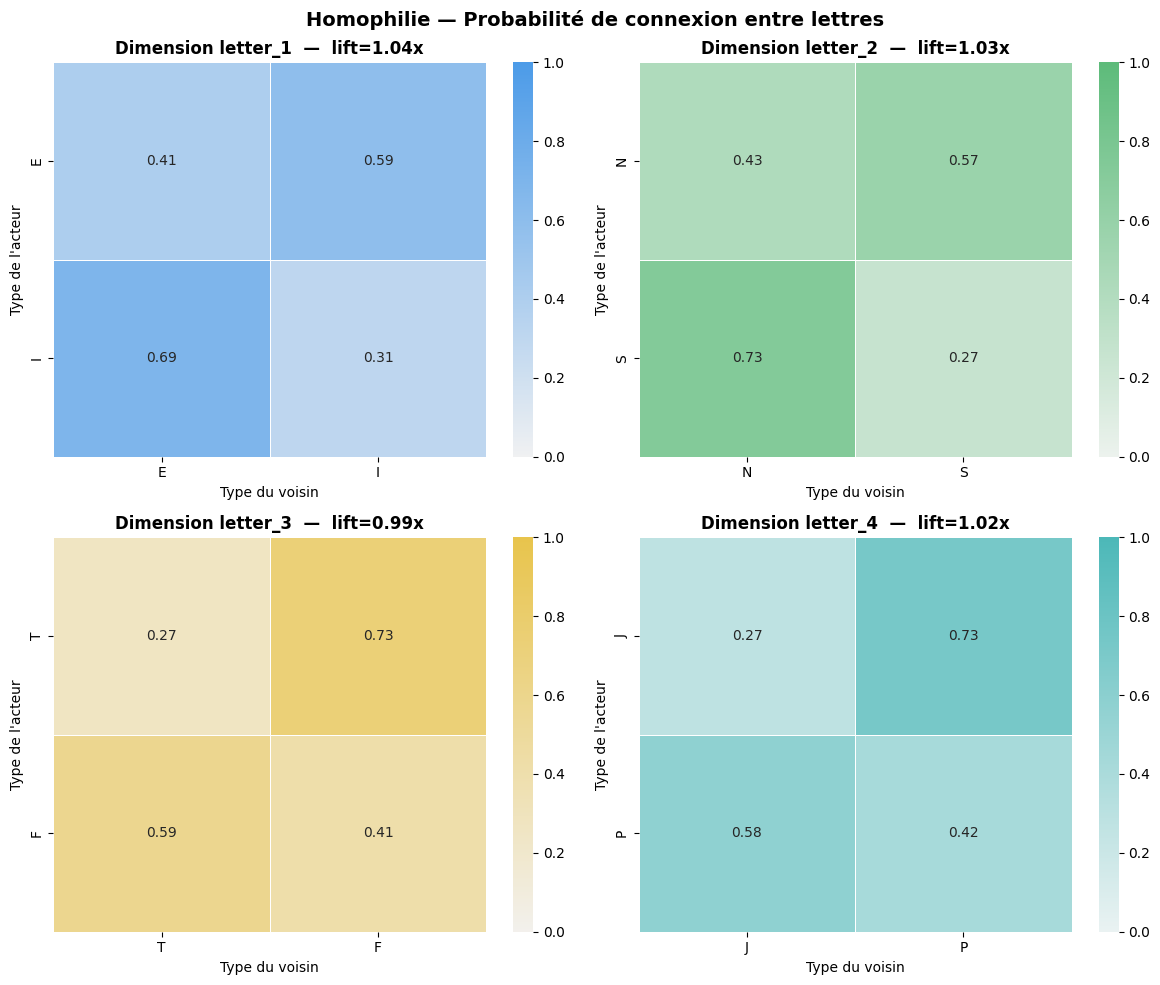

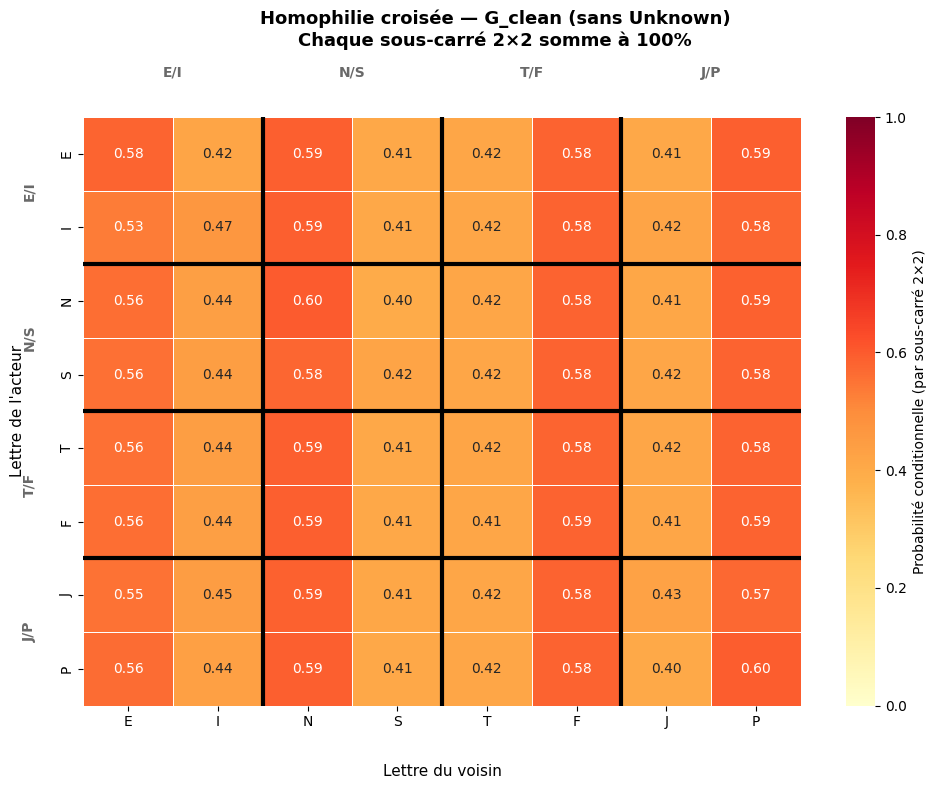


══════ Paires de lettres les plus co-occurentes ══════
  P → N  :  0.592
  T → N  :  0.591
  E → N  :  0.591
  E → P  :  0.590
  F → N  :  0.590
  I → N  :  0.590
  J → N  :  0.588
  N → P  :  0.587
  F → P  :  0.585
  T → P  :  0.584


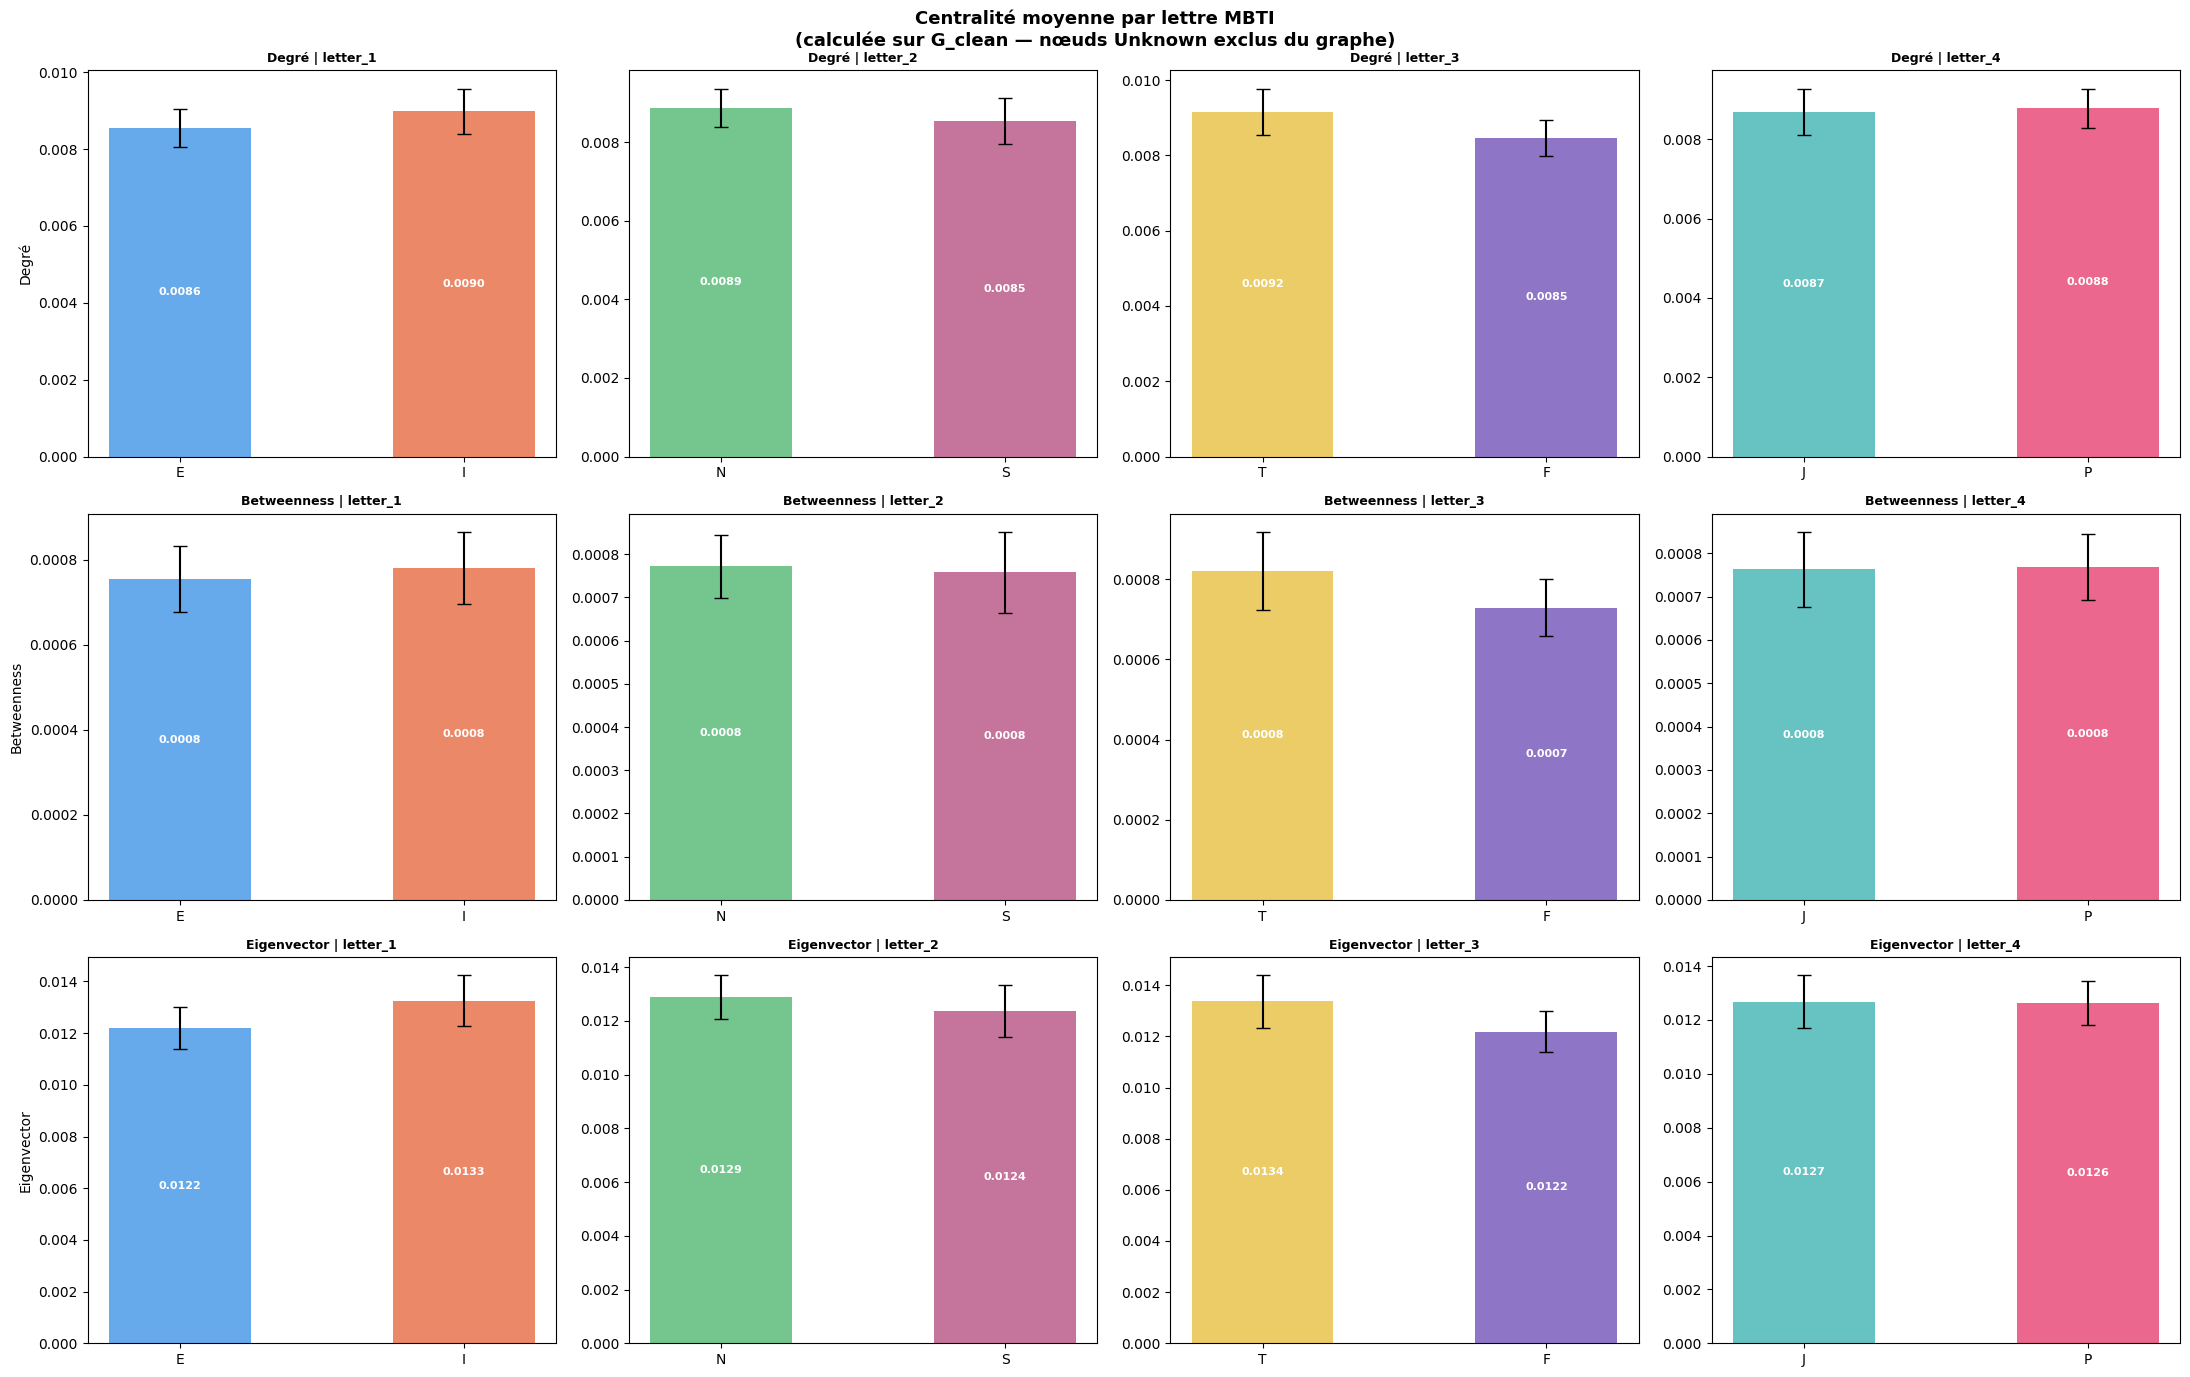


══════ Top 10 acteurs par betweenness — G_clean ══════
                  letter_1 letter_2 letter_3 letter_4  betweenness_c_clean
actor                                                                     
Samuel L. Jackson        E        S        T        P             0.019759
Anupam Kher              E        S        F        J             0.012453
Robert De Niro           I        S        T        J             0.010735
Steve Buscemi            E        N        F        P             0.010460
Alec Baldwin             E        S        T        J             0.010374
Bruce Willis             I        S        F        J             0.010303
Jim Broadbent            I        N        T        P             0.009708
Robin Williams           E        N        F        P             0.009349
Brad Pitt                I        S        F        P             0.008679
Ben Affleck              E        S        T        P             0.008647


In [ ]:
DIMENSIONS = {
    "letter_1": ("E", "I"),
    "letter_2": ("N", "S"),
    "letter_3": ("T", "F"),
    "letter_4": ("J", "P"),
}

DIM_COLORS = {
    "letter_1": ("#4C9BE8", "#E8734C"),
    "letter_2": ("#5DBB7A", "#BB5D8A"),
    "letter_3": ("#E8C44C", "#7A5DBB"),
    "letter_4": ("#4CB8B8", "#E84C7A"),
}

nodes_df = pd.DataFrame.from_dict(dict(G.nodes(data=True)), orient='index')
nodes_df.index.name = "actor"

known_df = nodes_df[nodes_df[['letter_1', 'letter_2', 'letter_3', 'letter_4']].ne("Unknown").all(axis=1)].copy()
print(f"Noeuds total   : {len(nodes_df):,}")
print(f"Noeuds connus  : {len(known_df):,}  ({100*len(known_df)/len(nodes_df):.1f}%)")
print(f"Noeuds Unknown : {len(nodes_df)-len(known_df):,}")

valid_nodes = known_df.index
G_clean = G.subgraph(valid_nodes).copy()


# HOMOPHILIE PAR DIMENSION

def homophily_score(G, attribute):
    same = total = 0
    for u, v in G.edges():
        a1 = G.nodes[u].get(attribute, "Unknown")
        a2 = G.nodes[v].get(attribute, "Unknown")
        if a1 == "Unknown" or a2 == "Unknown":
            continue
        total += 1
        if a1 == a2:
            same += 1
    observed = same / total if total > 0 else 0
    values   = [G.nodes[n].get(attribute) for n in G.nodes()
                if G.nodes[n].get(attribute) not in (None, "Unknown")]
    counts   = Counter(values)
    n        = sum(counts.values())
    expected = sum((c/n)**2 for c in counts.values())
    return {"observed": observed, "expected": expected,
            "lift": observed / expected if expected > 0 else 0,
            "n_edges": total}

print("\n══════ Homophilie par dimension MBTI ══════")
homophily_results = {}
for dim in DIMENSIONS:
    res = homophily_score(G_clean, dim)
    homophily_results[dim] = res
    print(f"  {dim}  | Observé={res['observed']:.3f}  Attendu={res['expected']:.3f}  "
          f"Lift={res['lift']:.2f}x  (sur {res['n_edges']:,} arêtes)")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Homophilie — Probabilité de connexion entre lettres", fontsize=14, fontweight='bold')

for ax, (dim, (l1, l2)) in zip(axes.flatten(), DIMENSIONS.items()):
    c1, c2      = DIM_COLORS[dim]
    labels      = [l1, l2]
    edge_counts = defaultdict(int)
    for u, v in G_clean.edges():
        a1 = G_clean.nodes[u].get(dim)
        a2 = G_clean.nodes[v].get(dim)
        edge_counts[tuple(sorted([a1, a2]))] += 1
    matrix = np.zeros((2, 2))
    for i, li in enumerate(labels):
        row_total = sum(edge_counts[tuple(sorted([li, lj]))] for lj in labels)
        for j, lj in enumerate(labels):
            matrix[i, j] = edge_counts[tuple(sorted([li, lj]))] / row_total if row_total > 0 else 0
    cmap = sns.light_palette(c1, as_cmap=True)
    sns.heatmap(matrix, annot=True, fmt=".2f", xticklabels=labels, yticklabels=labels,
                cmap=cmap, ax=ax, vmin=0, vmax=1, linewidths=0.5, linecolor='white')
    ax.set_title(f"Dimension {dim}  —  lift={homophily_results[dim]['lift']:.2f}x",
                 fontweight='bold')
    ax.set_xlabel("Type du voisin")
    ax.set_ylabel("Type de l'acteur")

plt.tight_layout()
plt.show()


# HOMOPHILIE CROISÉE

ALL_LETTERS = ["E", "I", "N", "S", "T", "F", "J", "P"]

DIM_LETTERS = {
    "letter_1": ["E", "I"],
    "letter_2": ["N", "S"],
    "letter_3": ["T", "F"],
    "letter_4": ["J", "P"],
}

LETTER_TO_DIM = {}
for dim, letters in DIM_LETTERS.items():
    for l in letters:
        LETTER_TO_DIM[l] = dim

# ── Comptage brut : toutes combinaisons lu × lv ──────────────────
cross_edge_counts = defaultdict(int)

for u, v in G_clean.edges():
    letters_u = [G_clean.nodes[u].get(dim) for dim in DIMENSIONS
                 if G_clean.nodes[u].get(dim) not in (None, "Unknown")]
    letters_v = [G_clean.nodes[v].get(dim) for dim in DIMENSIONS
                 if G_clean.nodes[v].get(dim) not in (None, "Unknown")]
    for lu in letters_u:
        for lv in letters_v:
            cross_edge_counts[(lu, lv)] += 1
            cross_edge_counts[(lv, lu)] += 1

# ── Normalisation : chaque sous-carré 2×2 somme à 1 ─────────────
# Pour li (dim_src) × bloc dim_dst → on divise par le total du bloc
n = len(ALL_LETTERS)
matrix_cross = np.zeros((n, n))

for i, li in enumerate(ALL_LETTERS):
    for dim_dst, letters_dst in DIM_LETTERS.items():
        total_bloc = sum(cross_edge_counts[(li, lj)] for lj in letters_dst)
        for lj in letters_dst:
            j = ALL_LETTERS.index(lj)
            matrix_cross[i, j] = (cross_edge_counts[(li, lj)] / total_bloc
                                   if total_bloc > 0 else 0)

# ── Visualisation ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle("Homophilie croisée — G_clean (sans Unknown)\n"
             "Chaque sous-carré 2×2 somme à 100%",
             fontsize=13, fontweight='bold')

sns.heatmap(matrix_cross, annot=True, fmt=".2f",
            xticklabels=ALL_LETTERS, yticklabels=ALL_LETTERS,
            cmap="YlOrRd", ax=ax, vmin=0, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={"label": "Probabilité conditionnelle (par sous-carré 2×2)"})

# Traits épais entre les blocs de 2
for pos in [2, 4, 6]:
    ax.axhline(pos, color='black', linewidth=3)
    ax.axvline(pos, color='black', linewidth=3)

# Annotations des blocs
for label, pos in [("E/I", 1), ("N/S", 3), ("T/F", 5), ("J/P", 7)]:
    ax.text(pos, -0.6, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='dimgray')
    ax.text(-0.6, pos, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color='dimgray', rotation=90)

ax.set_xlabel("Lettre du voisin", fontsize=11, labelpad=25)
ax.set_ylabel("Lettre de l'acteur", fontsize=11, labelpad=25)

plt.tight_layout()
plt.show()

# ── Top 10 paires les plus co-occurentes (hors diagonale) ────────
print("\n══════ Paires de lettres les plus co-occurentes ══════")
pairs = [
    (matrix_cross[i, j], li, lj)
    for i, li in enumerate(ALL_LETTERS)
    for j, lj in enumerate(ALL_LETTERS)
    if LETTER_TO_DIM[li] != LETTER_TO_DIM[lj]  # hors blocs diagonaux
]
for prob, li, lj in sorted(pairs, reverse=True)[:10]:
    print(f"  {li} → {lj}  :  {prob:.3f}")

# CENTRALITÉ

degree_c_clean      = nx.degree_centrality(G_clean)
betweenness_c_clean = nx.betweenness_centrality(G_clean, normalized=True)
try:
    eigenvector_c_clean = nx.eigenvector_centrality(G_clean, max_iter=1000, tol=1e-6)
except nx.PowerIterationFailedConvergence:
    eigenvector_c_clean = {n: 0 for n in G_clean.nodes()}
    print(" eigenvector_centrality (G_clean) n'a pas convergé")

known_df["degree_c_clean"]      = known_df.index.map(degree_c_clean)
known_df["betweenness_c_clean"] = known_df.index.map(betweenness_c_clean)
known_df["eigenvector_c_clean"] = known_df.index.map(eigenvector_c_clean)

CENTRALITIES_CLEAN = {
    "Degré":       "degree_c_clean",
    "Betweenness": "betweenness_c_clean",
    "Eigenvector": "eigenvector_c_clean",
}

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
fig.suptitle("Centralité moyenne par lettre MBTI\n(calculée sur G_clean — nœuds Unknown exclus du graphe)",
             fontsize=13, fontweight='bold')

for row_idx, (cent_name, cent_col) in enumerate(CENTRALITIES_CLEAN.items()):
    for col_idx, (dim, (l1, l2)) in enumerate(DIMENSIONS.items()):
        ax     = axes[row_idx][col_idx]
        c1, c2 = DIM_COLORS[dim]
        sub    = known_df[known_df[dim].isin([l1, l2])]
        means  = sub.groupby(dim)[cent_col].mean().reindex([l1, l2])
        cis    = sub.groupby(dim)[cent_col].sem().reindex([l1, l2]) * 1.96
        bars   = ax.bar([l1, l2], means.values, yerr=cis.values, capsize=5,
                        color=[c1, c2], alpha=0.85, width=0.5)
        ax.set_title(f"{cent_name} | {dim}", fontsize=9, fontweight='bold')
        ax.set_ylabel(cent_name if col_idx == 0 else "")
        for bar, val in zip(bars, means.values):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                        f"{val:.4f}", ha='center', va='center',
                        fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n══════ Top 10 acteurs par betweenness — G_clean ══════")
top10_clean = (known_df
               .sort_values("betweenness_c_clean", ascending=False)
               .head(10)[["letter_1", "letter_2", "letter_3", "letter_4", "betweenness_c_clean"]])
print(top10_clean.to_string())